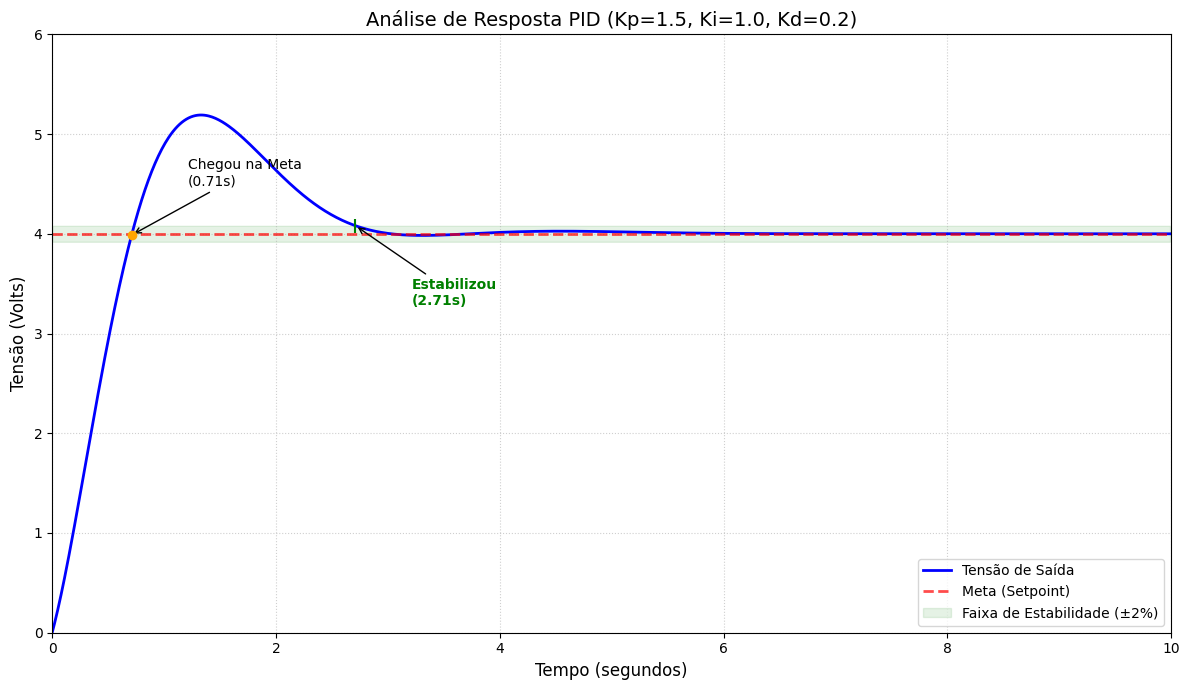

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# PASSO 1: CONFIGURAÇÕES GERAIS
# ==============================================================================
# Configuração de Tempo
duration = 10.0       # Duração total da simulação (segundos)
dt = 0.01             # Resolução (passo de cálculo: 10ms)
time = np.arange(0, duration, dt)

# Configuração da Meta (Setpoint)
setpoint_val = 4.0    # Tensão alvo (Volts)
setpoint = np.full_like(time, setpoint_val)

# Critério de Estabilização (Para análise do gráfico)
tolerancia_pct = 0.02 # 2% de tolerância (Padrão industrial)
limite_superior = setpoint_val * (1 + tolerancia_pct) # 4.08V
limite_inferior = setpoint_val * (1 - tolerancia_pct) # 3.92V

# ==============================================================================
# PASSO 2: SINTONIA DO PID E FÍSICA DO SISTEMA
# ==============================================================================
# Parâmetros do PID (Ajuste aqui para testar comportamentos)
Kp = 1.5    # Força proporcional (Arrancada)
Ki = 1.0    # Acúmulo de erro (Remove erro final, mas oscila)
Kd = 0.2    # Amortecimento (Freio para evitar oscilação)

# Parâmetros da "Planta" (O Hardware simulado)
inertia = 0.2       # Resistência à mudança (como um capacitor grande)
damping = 0.5       # Resistência natural (perdas no circuito)

# ==============================================================================
# PASSO 3: LOOP DE SIMULAÇÃO (CÁLCULO MATEMÁTICO)
# ==============================================================================
output = np.zeros_like(time)
velocity = 0.0
integral = 0.0
last_error = 0.0

for i in range(1, len(time)):
    # 1. Medir o erro atual
    current_value = output[i-1]
    error = setpoint_val - current_value
    
    # 2. Calcular termos PID
    P = Kp * error
    
    integral += error * dt
    I = Ki * integral
    
    D = Kd * (error - last_error) / dt
    last_error = error
    
    # 3. Sinal de Controle
    pid_signal = P + I + D
    
    # 4. Aplicar na Física do Sistema (Segunda Lei de Newton aplicada)
    acceleration = (pid_signal - (damping * velocity)) / inertia
    velocity += acceleration * dt
    output[i] = output[i-1] + (velocity * dt)
    
    # Trava física: Tensão não pode ser negativa
    if output[i] < 0: output[i] = 0

# ==============================================================================
# PASSO 4: ANÁLISE AUTOMÁTICA DOS DADOS
# ==============================================================================
# A. Encontrar a primeira vez que cruzou a meta (Tempo de Subida)
# Procura onde o valor passa de menor que 4.0 para maior que 4.0
indices_cruzamento = np.where(np.diff(np.sign(output - setpoint_val)))[0]
idx_primeiro_toque = indices_cruzamento[0] if len(indices_cruzamento) > 0 else None

# B. Encontrar o Tempo de Estabilização (Settling Time)
# Procura o último momento em que o sinal esteve FORA da faixa de 2%
fora_da_faixa = np.where((output > limite_superior) | (output < limite_inferior))[0]

if len(fora_da_faixa) > 0:
    idx_estabilizacao = fora_da_faixa[-1] # O último ponto instável
    tempo_estabilizacao = time[idx_estabilizacao]
    val_estabilizacao = output[idx_estabilizacao]
else:
    idx_estabilizacao = 0
    tempo_estabilizacao = 0

# ==============================================================================
# PASSO 5: GERAÇÃO DO GRÁFICO PROFISSIONAL
# ==============================================================================
plt.figure(figsize=(12, 7))

# 1. Plotar Linhas Principais
plt.plot(time, output, 'b-', linewidth=2, label='Tensão de Saída')
plt.plot(time, setpoint, 'r--', linewidth=2, alpha=0.7, label='Meta (Setpoint)')

# 2. Desenhar a Faixa de Tolerância (Zona Verde)
plt.fill_between(time, limite_inferior, limite_superior, color='green', alpha=0.1, label='Faixa de Estabilidade (±2%)')

# 3. Marcar o Primeiro Toque na Meta
if idx_primeiro_toque is not None:
    t_toque = time[idx_primeiro_toque]
    v_toque = output[idx_primeiro_toque]
    plt.scatter(t_toque, v_toque, color='orange', zorder=5)
    plt.annotate(f'Chegou na Meta\n({t_toque:.2f}s)', 
                 xy=(t_toque, v_toque), xytext=(t_toque + 0.5, v_toque + 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

# 4. Marcar o Ponto de Estabilização Definitiva
if idx_estabilizacao > 0 and idx_estabilizacao < len(time)-1:
    plt.scatter(tempo_estabilizacao, val_estabilizacao, color='green', s=100, zorder=5, marker='|')
    plt.annotate(f'Estabilizou\n({tempo_estabilizacao:.2f}s)', 
                 xy=(tempo_estabilizacao, val_estabilizacao), 
                 xytext=(tempo_estabilizacao + 0.5, val_estabilizacao - 0.8),
                 arrowprops=dict(facecolor='green', arrowstyle='->'),
                 color='green', fontweight='bold')

# Configurações Finais
plt.title(f"Análise de Resposta PID (Kp={Kp}, Ki={Ki}, Kd={Kd})", fontsize=14)
plt.xlabel("Tempo (segundos)", fontsize=12)
plt.ylabel("Tensão (Volts)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim(0, 6)
plt.xlim(0, 10)

plt.tight_layout()
plt.show()

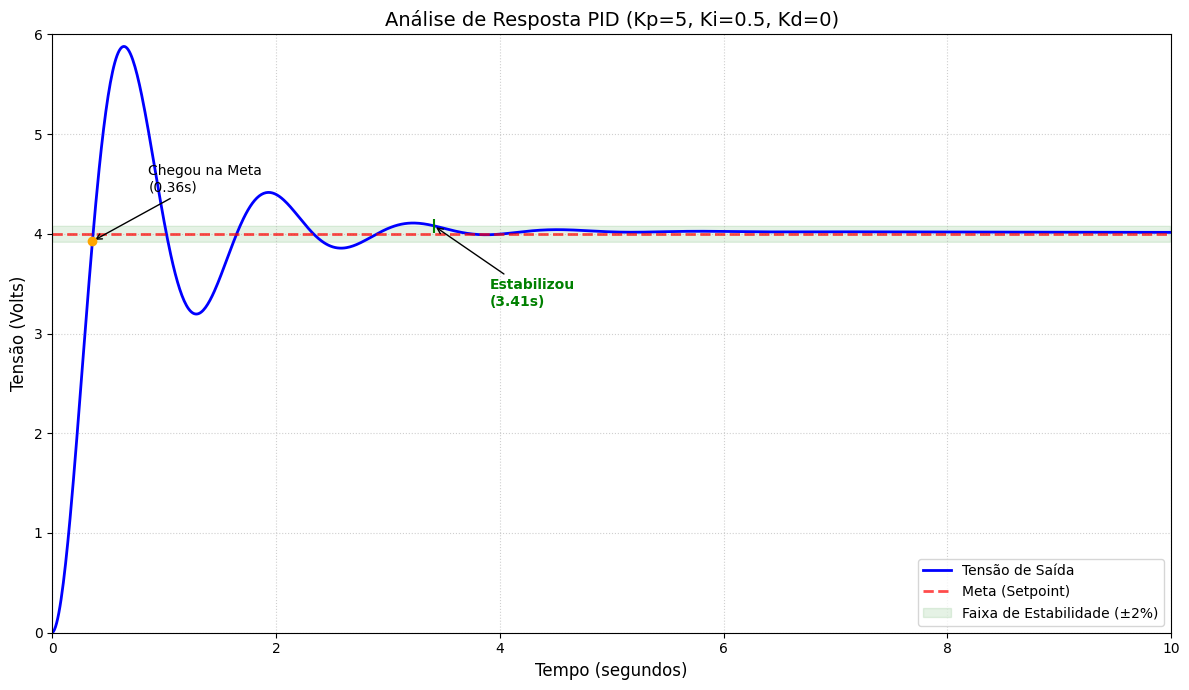

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# PASSO 1: CONFIGURAÇÕES GERAIS
# ==============================================================================
# Configuração de Tempo
duration = 10.0       # Duração total da simulação (segundos)
dt = 0.01             # Resolução (passo de cálculo: 10ms)
time = np.arange(0, duration, dt)

# Configuração da Meta (Setpoint)
setpoint_val = 4.0    # Tensão alvo (Volts)
setpoint = np.full_like(time, setpoint_val)

# Critério de Estabilização (Para análise do gráfico)
tolerancia_pct = 0.02 # 2% de tolerância (Padrão industrial)
limite_superior = setpoint_val * (1 + tolerancia_pct) # 4.08V
limite_inferior = setpoint_val * (1 - tolerancia_pct) # 3.92V

# ==============================================================================
# PASSO 2: SINTONIA DO PID E FÍSICA DO SISTEMA
# ==============================================================================
# Parâmetros do PID (Ajuste aqui para testar comportamentos)
Kp = 5    # Força proporcional (Arrancada)
Ki = 0.5    # Acúmulo de erro (Remove erro final, mas oscila)
Kd = 0    # Amortecimento (Freio para evitar oscilação)

# Parâmetros da "Planta" (O Hardware simulado)
inertia = 0.2       # Resistência à mudança (como um capacitor grande)
damping = 0.5       # Resistência natural (perdas no circuito)

# ==============================================================================
# PASSO 3: LOOP DE SIMULAÇÃO (CÁLCULO MATEMÁTICO)
# ==============================================================================
output = np.zeros_like(time)
velocity = 0.0
integral = 0.0
last_error = 0.0

for i in range(1, len(time)):
    # 1. Medir o erro atual
    current_value = output[i-1]
    error = setpoint_val - current_value
    
    # 2. Calcular termos PID
    P = Kp * error
    
    integral += error * dt
    I = Ki * integral
    
    D = Kd * (error - last_error) / dt
    last_error = error
    
    # 3. Sinal de Controle
    pid_signal = P + I + D
    
    # 4. Aplicar na Física do Sistema (Segunda Lei de Newton aplicada)
    acceleration = (pid_signal - (damping * velocity)) / inertia
    velocity += acceleration * dt
    output[i] = output[i-1] + (velocity * dt)
    
    # Trava física: Tensão não pode ser negativa
    if output[i] < 0: output[i] = 0

# ==============================================================================
# PASSO 4: ANÁLISE AUTOMÁTICA DOS DADOS
# ==============================================================================
# A. Encontrar a primeira vez que cruzou a meta (Tempo de Subida)
# Procura onde o valor passa de menor que 4.0 para maior que 4.0
indices_cruzamento = np.where(np.diff(np.sign(output - setpoint_val)))[0]
idx_primeiro_toque = indices_cruzamento[0] if len(indices_cruzamento) > 0 else None

# B. Encontrar o Tempo de Estabilização (Settling Time)
# Procura o último momento em que o sinal esteve FORA da faixa de 2%
fora_da_faixa = np.where((output > limite_superior) | (output < limite_inferior))[0]

if len(fora_da_faixa) > 0:
    idx_estabilizacao = fora_da_faixa[-1] # O último ponto instável
    tempo_estabilizacao = time[idx_estabilizacao]
    val_estabilizacao = output[idx_estabilizacao]
else:
    idx_estabilizacao = 0
    tempo_estabilizacao = 0

# ==============================================================================
# PASSO 5: GERAÇÃO DO GRÁFICO PROFISSIONAL
# ==============================================================================
plt.figure(figsize=(12, 7))

# 1. Plotar Linhas Principais
plt.plot(time, output, 'b-', linewidth=2, label='Tensão de Saída')
plt.plot(time, setpoint, 'r--', linewidth=2, alpha=0.7, label='Meta (Setpoint)')

# 2. Desenhar a Faixa de Tolerância (Zona Verde)
plt.fill_between(time, limite_inferior, limite_superior, color='green', alpha=0.1, label='Faixa de Estabilidade (±2%)')

# 3. Marcar o Primeiro Toque na Meta
if idx_primeiro_toque is not None:
    t_toque = time[idx_primeiro_toque]
    v_toque = output[idx_primeiro_toque]
    plt.scatter(t_toque, v_toque, color='orange', zorder=5)
    plt.annotate(f'Chegou na Meta\n({t_toque:.2f}s)', 
                 xy=(t_toque, v_toque), xytext=(t_toque + 0.5, v_toque + 0.5),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))

# 4. Marcar o Ponto de Estabilização Definitiva
if idx_estabilizacao > 0 and idx_estabilizacao < len(time)-1:
    plt.scatter(tempo_estabilizacao, val_estabilizacao, color='green', s=100, zorder=5, marker='|')
    plt.annotate(f'Estabilizou\n({tempo_estabilizacao:.2f}s)', 
                 xy=(tempo_estabilizacao, val_estabilizacao), 
                 xytext=(tempo_estabilizacao + 0.5, val_estabilizacao - 0.8),
                 arrowprops=dict(facecolor='green', arrowstyle='->'),
                 color='green', fontweight='bold')

# Configurações Finais
plt.title(f"Análise de Resposta PID (Kp={Kp}, Ki={Ki}, Kd={Kd})", fontsize=14)
plt.xlabel("Tempo (segundos)", fontsize=12)
plt.ylabel("Tensão (Volts)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.ylim(0, 6)
plt.xlim(0, 10)

plt.tight_layout()
plt.show()